In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

### STEP 1 Train and test on the row data

In [4]:
# 1. Load Data
# We use low_memory=False to avoid DtypeWarnings with large files
train_transactions = pd.read_csv('train_transactions.csv', low_memory=False) # [cite: 59, 81]
train_users = pd.read_csv('train_users.csv', low_memory=False) # [cite: 60, 96]

# 2. Memory Optimization (Crucial for M1 RAM)
def optimize_floats(df):
    floats = df.select_dtypes(include=['float64']).columns
    df[floats] = df[floats].astype('float32')
    return df

def optimize_ints(df):
    ints = df.select_dtypes(include=['int64']).columns
    df[ints] = df[ints].astype('int32')
    return df

# 3. Basic Cleaning
# error_group is empty for successful transactions [cite: 88]
train_transactions['error_group'] = train_transactions['error_group'].fillna('no_error')

# Fill other missing values with 'Unknown' for categories
cat_cols_tr = ['status', 'transaction_type', 'currency', 'card_brand', 'card_type', 'card_country', 'payment_country']
train_transactions[cat_cols_tr] = train_transactions[cat_cols_tr].fillna('Unknown')

# 4. Merge Datasets [cite: 82, 97]
# We merge on id_user to link transaction behavior to the is_fraud label
df = pd.merge(train_transactions, train_users, on='id_user', how='inner')

# 5. Type Transformation
# We use format='ISO8601' to handle varying microsecond precision
# and utc=True to correctly parse the +00:00 offset 
df['timestamp_tr'] = pd.to_datetime(df['timestamp_tr'], format='ISO8601', utc=True)
df['timestamp_reg'] = pd.to_datetime(df['timestamp_reg'], format='ISO8601', utc=True)

# Convert categorical strings to 'category' dtype for LightGBM efficiency
categorical_features = ['status', 'transaction_type', 'error_group', 'currency', 
                        'card_brand', 'card_type', 'card_country', 'payment_country', 
                        'gender', 'reg_country', 'traffic_type']

for col in categorical_features:
    df[col] = df[col].astype('category')

# 6. Drop High-Cardinality/Unique strings (not useful for a raw baseline)
# email and card_holder have too many unique values for a basic tree [cite: 94, 99]
cols_to_drop = ['id_user', 'email', 'card_holder', 'card_mask_hash', 'timestamp_tr', 'timestamp_reg']
X = df.drop(columns=['is_fraud'] + cols_to_drop)
y = df['is_fraud'] # 

from sklearn.model_selection import StratifiedKFold

# 7. Setup 5-Fold Cross-Validation
# This ensures each fold has the same 16.6% fraud ratio
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []

print(f"Starting Stratified 5-Fold Cross-Validation...")

# 8. The Cross-Validation Loop
# We use .iloc because X and y are Pandas objects
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_f, X_val_f = X.iloc[train_idx], X.iloc[val_idx]
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]
    
    # Re-initialize the model for each fold to prevent "memory" leaks
    fold_model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        is_unbalance=True, 
        importance_type='gain', # Better for identifying your "Top 5" features [cite: 47]
        random_state=42
    )
    
    # Train on 80% of the data
    fold_model.fit(X_train_f, y_train_f)
    
    # Validate on the remaining 20%
    preds = fold_model.predict(X_val_f)
    score = f1_score(y_val_f, preds)
    fold_metrics.append(score)
    
    print(f"Fold {fold} F1-Score: {score:.4f}")

# 9. Final Performance Summary
print("\n" + "="*30)
print(f"Final Mean F1-Score: {np.mean(fold_metrics):.4f}")
print(f"Stability (Std Dev): {np.std(fold_metrics):.4f}")
print("="*30)

Starting Stratified 5-Fold Cross-Validation...
[LightGBM] [Info] Number of positive: 417917, number of negative: 2090385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 2508302, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166614 -> initscore=-1.609821
[LightGBM] [Info] Start training from score -1.609821
Fold 1 F1-Score: 0.4462
[LightGBM] [Info] Number of positive: 417917, number of negative: 2090385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 881
[LightGBM] [Info] Number of data p

### STEP 2 Feature engineering from Ira

Створення 'Золотих' фіч...

Початок крос-валідації на 3135378 записах...
Fold 1 F1-Score: 0.4855
Fold 2 F1-Score: 0.4850
Fold 3 F1-Score: 0.4839
Fold 4 F1-Score: 0.4841
Fold 5 F1-Score: 0.4840

Final Mean F1-Score: 0.4845
Stability (Std Dev): 0.0006


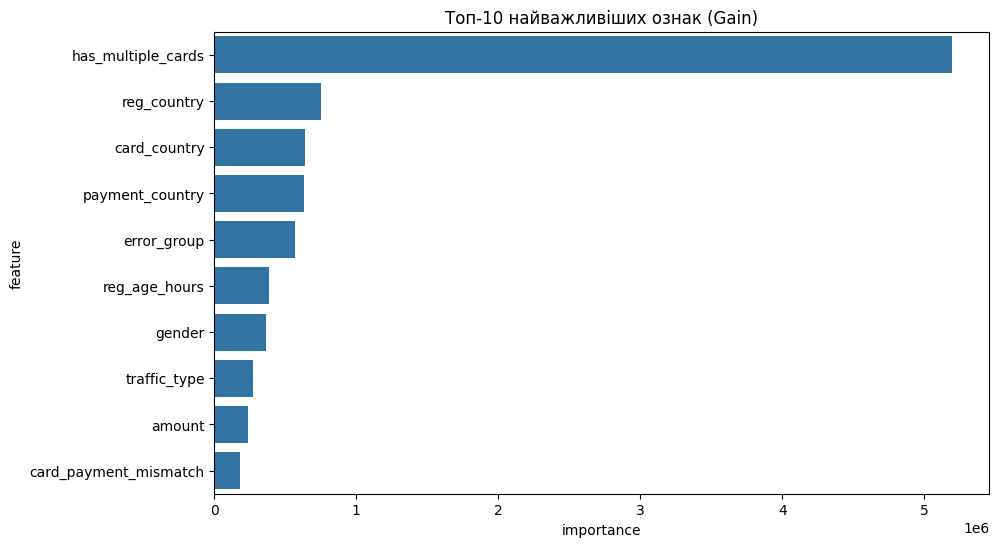

In [8]:
# 1. Завантаження даних
train_transactions = pd.read_csv('train_transactions.csv', low_memory=False)
train_users = pd.read_csv('train_users.csv', low_memory=False)

# Перетворення типів (як ми робили раніше)
train_transactions['timestamp_tr'] = pd.to_datetime(train_transactions['timestamp_tr'], format='ISO8601', utc=True)
train_users['timestamp_reg'] = pd.to_datetime(train_users['timestamp_reg'], format='ISO8601', utc=True)

# 2. Об'єднання для створення фіч
df = pd.merge(train_transactions, train_users, on='id_user', how='inner')

print("Створення 'Золотих' фіч...")

# --- FEATURE ENGINEERING ---

# 1. Triple Mismatch (Реєстрація != Картка != Платіж)
# Це ваш "абсолютний чемпіон"
df['triple_mismatch'] = ((df['reg_country'] != df['card_country']) & 
                         (df['card_country'] != df['payment_country']) & 
                         (df['reg_country'] != df['payment_country'])).astype(int)

# 2. Card/Payment Mismatch
df['card_payment_mismatch'] = (df['card_country'] != df['payment_country']).astype(int)

# 3. Card/Reg Mismatch
df['card_reg_mismatch'] = (df['card_country'] != df['reg_country']).astype(int)

# 4. Many Cards (>1 картки на акаунт)
# Рахуємо унікальні хеші карток для кожного користувача
df['unique_card_count'] = df.groupby('id_user')['card_mask_hash'].transform('nunique')
df['has_multiple_cards'] = (df['unique_card_count'] > 1).astype(int)

# 5. High Velocity (>3 транзакції за годину)
# Сортуємо, щоб часове вікно працювало коректно
df = df.sort_values(['id_user', 'timestamp_tr'])

# Рахуємо кількість транзакцій, використовуючи 'amount', бо 'id_user' тепер в індексі
# .values гарантує, що дані ляжуть точно в ті ж рядки (оскільки ми щойно відсортували df)
df['velocity_1h'] = df.groupby('id_user').rolling('1h', on='timestamp_tr')['amount'].count().values

df['is_high_velocity'] = (df['velocity_1h'] > 3).astype(int)

df['is_high_velocity'] = (df['velocity_1h'] > 3).astype(int)

# 6. Додатково: Швидка атака (час від реєстрації до транзакції < 1 год)
df['reg_age_hours'] = (df['timestamp_tr'] - df['timestamp_reg']).dt.total_seconds() / 3600
df['is_fast_attack'] = (df['reg_age_hours'] < 1).astype(int)

# --- ПІДГОТОВКА ДО НАВЧАННЯ ---

# Список колонок для видалення (непотрібні або унікальні рядки)
cols_to_drop = ['id_user', 'email', 'card_holder', 'card_mask_hash', 'timestamp_tr', 'timestamp_reg', 'unique_card_count', 'velocity_1h']

# Визначаємо категоріальні ознаки (включаючи нові бінарні фічі)
categorical_features = ['status', 'transaction_type', 'error_group', 'currency', 
                        'card_brand', 'card_type', 'card_country', 'payment_country', 
                        'gender', 'reg_country', 'traffic_type', 
                        'triple_mismatch', 'card_payment_mismatch', 'card_reg_mismatch', 
                        'has_multiple_cards', 'is_high_velocity', 'is_fast_attack']

for col in categorical_features:
    df[col] = df[col].astype('category')

X = df.drop(columns=['is_fraud'] + cols_to_drop)
y = df['is_fraud']

# 3. 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []

print(f"\nПочаток крос-валідації на {len(X)} записах...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_f, X_val_f = X.iloc[train_idx], X.iloc[val_idx]
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        is_unbalance=True, 
        importance_type='gain',
        random_state=42,
        verbosity=-1 # Менше логів
    )
    
    model.fit(X_train_f, y_train_f)
    preds = model.predict(X_val_f)
    score = f1_score(y_val_f, preds)
    fold_metrics.append(score)
    print(f"Fold {fold} F1-Score: {score:.4f}")

print("\n" + "="*30)
print(f"Final Mean F1-Score: {np.mean(fold_metrics):.4f}")
print(f"Stability (Std Dev): {np.std(fold_metrics):.4f}")
print("="*30)

# Подивимось, які фічі стали найважливішими
import matplotlib.pyplot as plt
import seaborn as sns

importance_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
importance_df = importance_df.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(10))
plt.title('Топ-10 найважливіших ознак (Gain)')
plt.show()

### STEP 3 revised FE+loop with different treshholds for best f1

Впровадження розширеного Feature Engineering...
Fold 1 | Best Threshold: 0.66 | Max F1: 0.6044
Fold 2 | Best Threshold: 0.66 | Max F1: 0.6013
Fold 3 | Best Threshold: 0.66 | Max F1: 0.6025
Fold 4 | Best Threshold: 0.66 | Max F1: 0.6065
Fold 5 | Best Threshold: 0.64 | Max F1: 0.6014

Mean F1-Score: 0.6032
Recommended Threshold: 0.66


/var/folders/ng/d1q3z1pj2jg39dq68wjclth40000gn/T/ipykernel_23001/2131201578.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(10), palette='viridis')


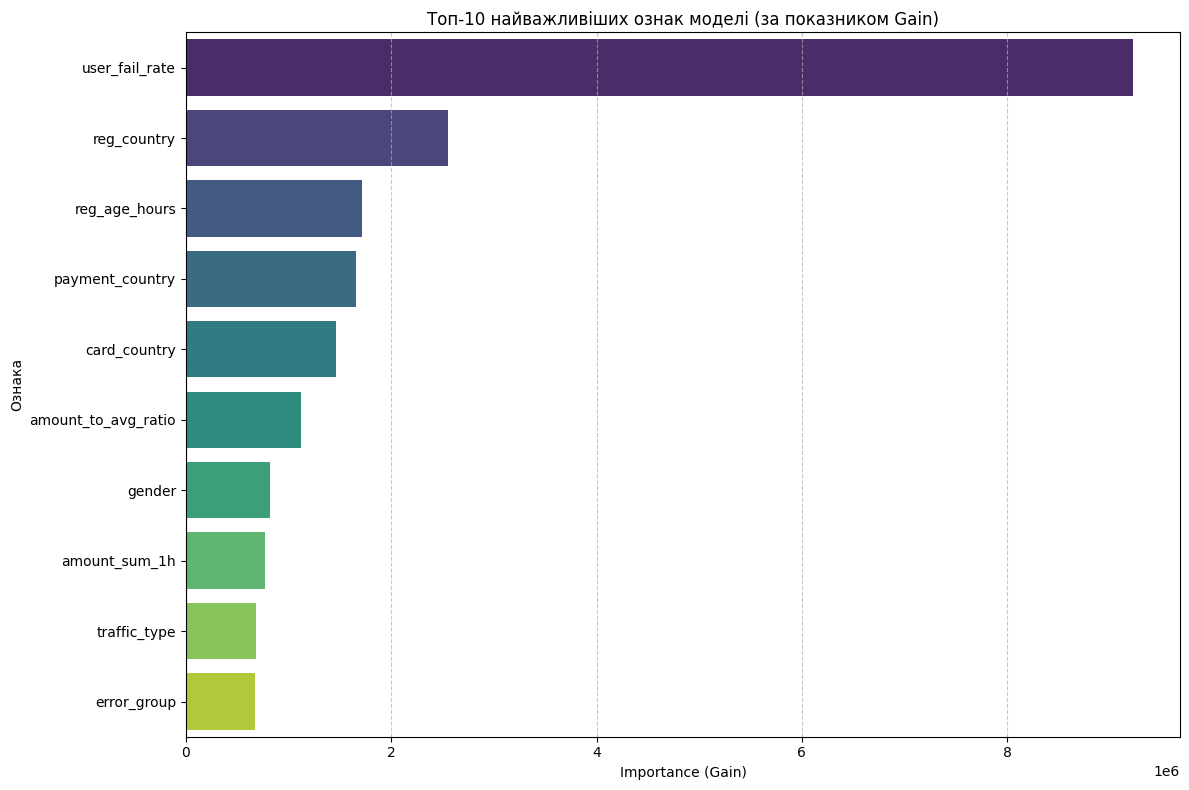


Топ-10 найважливіших ознак (текстовий список):
                feature    importance
15       user_fail_rate  9.221412e+06
10          reg_country  2.551226e+06
17        reg_age_hours  1.713629e+06
8       payment_country  1.652746e+06
7          card_country  1.461632e+06
20  amount_to_avg_ratio  1.125119e+06
9                gender  8.212493e+05
19        amount_sum_1h  7.714330e+05
11         traffic_type  6.839226e+05
3           error_group  6.775339e+05


In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns  # Додано для візуалізації

# 1. Завантаження та базова підготовка
train_transactions = pd.read_csv('train_transactions.csv', low_memory=False)
train_users = pd.read_csv('train_users.csv', low_memory=False)

train_transactions['timestamp_tr'] = pd.to_datetime(train_transactions['timestamp_tr'], format='ISO8601', utc=True)
train_users['timestamp_reg'] = pd.to_datetime(train_users['timestamp_reg'], format='ISO8601', utc=True)

df = pd.merge(train_transactions, train_users, on='id_user', how='inner')
df = df.sort_values(['id_user', 'timestamp_tr'])

print("Впровадження розширеного Feature Engineering...")

# --- 1. Текстовий аналіз та зворотні зв'язки ---
df['email_domain'] = df['email'].str.split('@').str[1]
df['users_per_card'] = df.groupby('card_mask_hash')['id_user'].transform('nunique')

def check_name_match(row):
    email_name = str(row['email']).split('@')[0].replace('.', ' ').lower()
    card_name = str(row['card_holder']).lower()
    return 1 if email_name in card_name or card_name in email_name else 0

df['name_in_email'] = df.apply(check_name_match, axis=1)

# --- 2. Поведінкові агрегації (User History) ---
df['user_fail_rate'] = df.groupby('id_user')['status'].transform(lambda x: (x == 'fail').mean())
df['is_cvv_error'] = (df['error_group'] == 'cvv_error').astype(int)
df['user_cvv_error_count'] = df.groupby('id_user')['is_cvv_error'].transform('sum')

# --- 3. Числові змінні ---
df['reg_age_hours'] = (df['timestamp_tr'] - df['timestamp_reg']).dt.total_seconds() / 3600
df['velocity_1h'] = df.groupby('id_user').rolling('1h', on='timestamp_tr')['amount'].count().values
df['amount_sum_1h'] = df.groupby('id_user').rolling('1h', on='timestamp_tr')['amount'].sum().values
df['avg_amount_user'] = df.groupby('id_user')['amount'].transform('mean')
df['amount_to_avg_ratio'] = df['amount'] / (df['avg_amount_user'] + 0.01)

# --- 4. Підготовка до навчання ---
categorical_features = ['status', 'transaction_type', 'error_group', 'currency', 
                        'card_brand', 'card_type', 'card_country', 'payment_country', 
                        'gender', 'reg_country', 'traffic_type', 'email_domain']

for col in categorical_features:
    df[col] = df[col].astype('category')

cols_to_drop = ['id_user', 'email', 'card_holder', 'card_mask_hash', 'timestamp_tr', 'timestamp_reg', 'is_cvv_error', 'avg_amount_user']
X = df.drop(columns=['is_fraud'] + cols_to_drop)
y = df['is_fraud']

# --- 5. Навчання та Тюнінг порогу ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_thresholds = []
fold_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=200, 
        learning_rate=0.05,
        is_unbalance=True,
        importance_type='gain',
        random_state=42,
        verbosity=-1
    )
    
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_val)[:, 1]
    
    thresholds = np.arange(0.1, 0.9, 0.02)
    scores = [f1_score(y_val, (y_probs >= t).astype(int)) for t in thresholds]
    
    best_t = thresholds[np.argmax(scores)]
    best_f1 = np.max(scores)
    
    best_thresholds.append(best_t)
    fold_f1_scores.append(best_f1)
    
    print(f"Fold {fold} | Best Threshold: {best_t:.2f} | Max F1: {best_f1:.4f}")

print("\n" + "="*30)
print(f"Mean F1-Score: {np.mean(fold_f1_scores):.4f}")
print(f"Recommended Threshold: {np.mean(best_thresholds):.2f}")
print("="*30)

# --- ДОДАНО: Візуалізація Топ-10 ознак ---
# Створюємо датафрейм з важливістю ознак
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10), palette='viridis')
plt.title('Топ-10 найважливіших ознак моделі (за показником Gain)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Ознака')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вивід списком у консоль
print("\nТоп-10 найважливіших ознак (текстовий список):")
print(feature_importances.head(10))